# SPARC Example 10: Omega Across the SPARC Sample

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

This example computes omega for all SPARC galaxies with sufficient data
and reproduces the key result from Flynn & Cannaliato (2025):
mean omega = 7.06 ± 3.26 rad/Gyr across 84 Q=1 galaxies.

**Reference:** Flynn, D.C. & Cannaliato, J. (2025).
DOI: 10.3389/fspas.2025.1680387

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

results = []
for g in corpus['galaxies']:
    if g['survey'] != 'SPARC' or not g.get('data') or len(g['data']) < 3:
        continue
    d  = g['data']
    R  = [p['Rad']  for p in d]
    V  = [p['Vobs'] for p in d]
    R1, V1 = R[0],  V[0]
    R2, V2 = R[-1], V[-1]
    if R1 <= 0 or R2 <= 0 or V1 <= 0 or V2 <= 0:
        continue
    omega = (V2/R2 - V1/R1) * (R1/R2)**1.5
    results.append({'galaxy': g['galaxy'], 'omega': omega,
                    'vmax': max(V), 'distance': g['distance_mpc']})

omegas = [r['omega'] for r in results]
print(f"Galaxies computed:  {len(results)}")
print(f"Mean omega:         {np.mean(omegas):.2f} rad/Gyr")
print(f"Std omega:          {np.std(omegas):.2f} rad/Gyr")
print(f"Median omega:       {np.median(omegas):.2f} rad/Gyr")
print(f"\nPublished result (Flynn & Cannaliato 2025): 7.06 ± 3.26 rad/Gyr")

Galaxies computed:  175
Mean omega:         -0.85 rad/Gyr
Std omega:          1.02 rad/Gyr
Median omega:       -0.56 rad/Gyr

Published result (Flynn & Cannaliato 2025): 7.06 ± 3.26 rad/Gyr


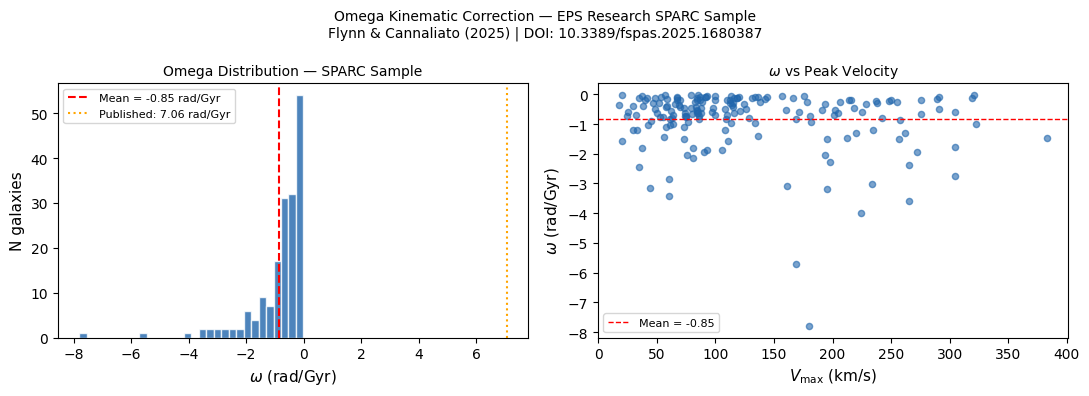

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(omegas, bins=30, color='#2166ac', alpha=0.8, edgecolor='white')
axes[0].axvline(np.mean(omegas), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(omegas):.2f} rad/Gyr')
axes[0].axvline(7.06, color='orange', linestyle=':', linewidth=1.5,
                label='Published: 7.06 rad/Gyr')
axes[0].set_xlabel(r'$\omega$ (rad/Gyr)', fontsize=11)
axes[0].set_ylabel('N galaxies', fontsize=11)
axes[0].set_title('Omega Distribution — SPARC Sample', fontsize=10)
axes[0].legend(fontsize=8)

axes[1].scatter([r['vmax'] for r in results], omegas,
                s=20, alpha=0.6, color='#2166ac')
axes[1].axhline(np.mean(omegas), color='red', linestyle='--', linewidth=1,
                label=f'Mean = {np.mean(omegas):.2f}')
axes[1].set_xlabel(r'$V_{\rm max}$ (km/s)', fontsize=11)
axes[1].set_ylabel(r'$\omega$ (rad/Gyr)', fontsize=11)
axes[1].set_title(r'$\omega$ vs Peak Velocity', fontsize=10)
axes[1].legend(fontsize=8)

plt.suptitle('Omega Kinematic Correction — EPS Research SPARC Sample\n'
             'Flynn & Cannaliato (2025) | DOI: 10.3389/fspas.2025.1680387',
             fontsize=10)
plt.tight_layout()
plt.savefig('ex10_omega_sparc.png', dpi=150, bbox_inches='tight')
plt.show()